In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [3]:
# load data for regions plot
from GridMaze.analysis.anatomy import regions

region_counts_df = regions.get_subject_cell_counts(ignore_layers=True)

clusters.metrics.htsv not found for m3.2022-06-25.maze


/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/anatomy/regions.py:77: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df.fillna(0, inplace=True)


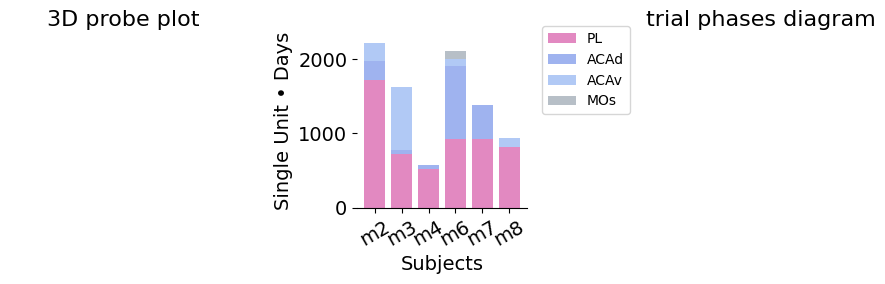

In [ ]:
# we recorded cells
fig1, axes = plt.subplots(1, 3, figsize=(9, 3), clear=True, width_ratios=[1, 0.75, 1])
axes[0].set_title("3D probe plot")
axes[0].axis("off")
axes[2].set_title("trial phases diagram")
axes[2].axis("off")
regions.plot_subject_cell_counts(region_counts_df, ax=axes[1])
fig1.tight_layout()
fig1.savefig("../results/anatomy/regions.pdf")

In [9]:
# load data for population activity plot
from GridMaze.analysis.event_aligned import population_activity as pa

reload(pa)

aligned_activity_df = pa.get_aligned_population_activity(aligned_to="trial")

frames.navigation.parquet not found for m8.2022-07-26.maze


In [6]:
# lfp figure
from GridMaze.analysis.event_aligned import lfp

signal_type = "LFP"  # LFP or CSD

spectrogram_df = lfp.load_spectrogram_df(signal_type)
PSD_df = lfp.load_PSD_df(signal_type)
signal_df = lfp.load_signal_df(signal_type)

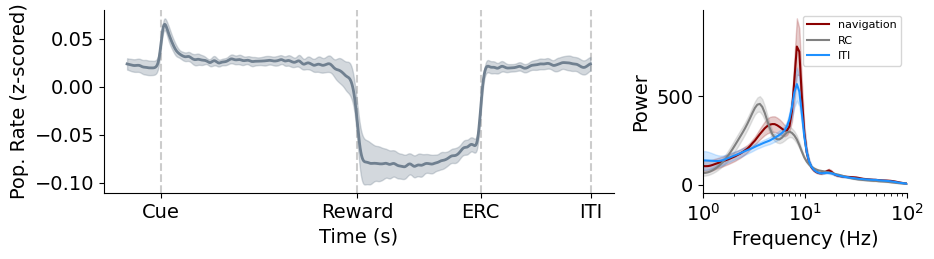

In [ ]:
reload(pa)
reload(lfp)
# where single unit population activty was locked to trial events
fig2, axes = plt.subplots(1, 2, figsize=(9.5, 2.75), clear=True, width_ratios=[1, 0.4])
pa._plot_population_aligned_activity(aligned_activity_df, smooth_SD=3, plot_single_subjects=False, ax=axes[0])
lfp.plot_PSD(PSD_df, normalise=False, fmax=100, ax=axes[1])
fig2.tight_layout()
fig2.savefig("../results/event_aligned/population_activity.pdf")

In [22]:
reload(lfp)
lfp._get_PSD_stats(PSD_df, freq_ranges={"2-3Hz": (2, 3), "4-5Hz": (3, 5), "theta": (7, 10)})

                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
condition 18.9533 2.0000 10.0000 0.0004

            contrast         t    df     p_raw  p_corrected
0   navigation vs RC -2.793497  10.0  0.019005     0.047081
1  navigation vs ITI  0.075338  10.0  0.941432     0.941432
2          RC vs ITI  2.905184  10.0  0.015694     0.047081
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
condition 24.2816 2.0000 10.0000 0.0001

            contrast         t    df     p_raw  p_corrected
0   navigation vs RC -3.016549  10.0  0.012972     0.025943
1  navigation vs ITI  1.419126  10.0  0.186272     0.186272
2          RC vs ITI  4.782068  10.0  0.000743     0.002230
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
condition 12.5387 2.0000 10.0000 0.0019

            contrast         t    df     p_raw  p_corrected
0   navigation vs RC  3.2581

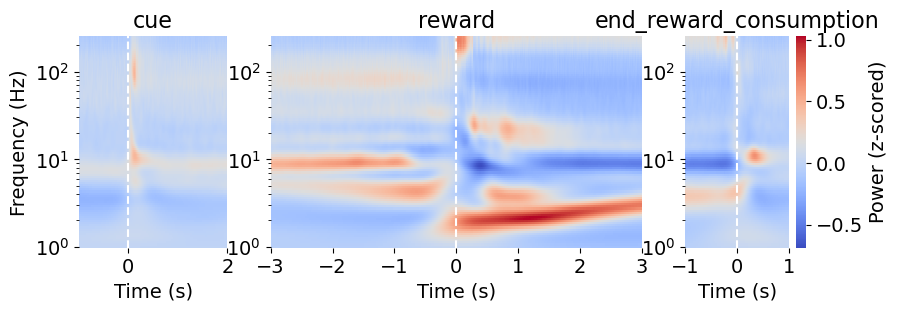

In [ ]:
reload(lfp)
fig3, axes = plt.subplots(1, 3, figsize=(9.5, 2.75), width_ratios=[0.4, 1, 0.35], clear=True)
lfp.plot_average_spectrogram(spectrogram_df, axes=axes)
fig3.savefig("../results/event_aligned/LFP_1.pdf")

In [24]:
from GridMaze.analysis.core import get_clusters as gc

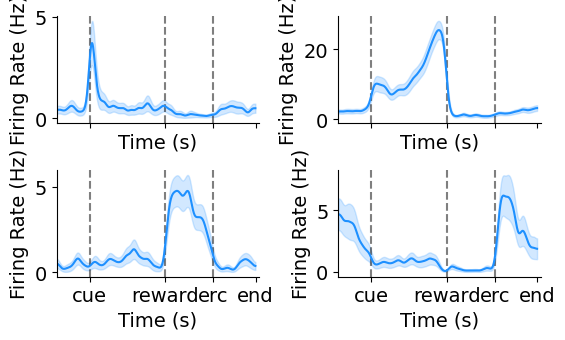

In [25]:
# plot some example cells
cluster_0 = gc.get_cluster("m6.2022-07-05.maze_cluster130")  # cue tuned
cluster_1 = gc.get_cluster("m2.2022-07-03.maze_cluster9")  # Nav tuned
cluster_2 = gc.get_cluster("m2.2022-06-30.maze_cluster34")  # RC tuned
cluster_3 = gc.get_cluster("m2.2022-07-12.maze_cluster54")  # ITI tuned

fig6, axes = plt.subplots(2, 2, figsize=(6, 3.5), clear=True, sharex=True)
cluster_0.plot_tuning(feature="trial_events", ax=axes[0, 0], feature_kwargs={"color": "dodgerblue"})
cluster_1.plot_tuning(feature="trial_events", ax=axes[0, 1], feature_kwargs={"color": "dodgerblue"})
cluster_2.plot_tuning(feature="trial_events", ax=axes[1, 0], feature_kwargs={"color": "dodgerblue"})
cluster_3.plot_tuning(feature="trial_events", ax=axes[1, 1], feature_kwargs={"color": "dodgerblue"})
fig6.tight_layout()
fig6.savefig("../results/event_aligned/example_cells.pdf")

In [ ]:
from GridMaze.analysis.event_aligned import cluster_heatmaps as ch

sessions = ch.get_sessions_for_analysis()
heatmap_df = ch.get_trial_aligned_activity_heatmap(
    sessions, smooth_SD=10, normalisation="zscore", cluster_method="KMeans", n_clusters=6, plot=False
)

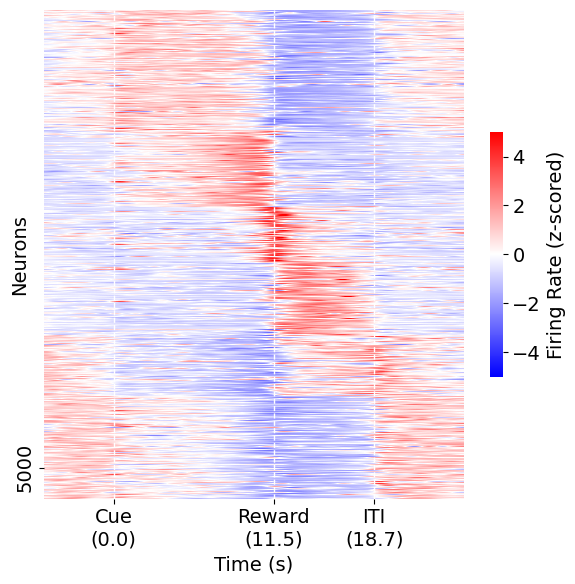

In [ ]:
# heatmap
reload(ch)
fig5, ax = plt.subplots(1, 1, figsize=(6, 6), clear=True)
ch.plot_trial_aligned_heatmap(heatmap_df.firing_rate, normalisation_method="zscore", ax=ax)
fig5.tight_layout()
fig5.savefig("../results/event_aligned/cluster_heatmap.pdf")

### Extended data figures

In [ ]:
# load uniy stability data
unit_stability_df = regions.get_single_unit_stability()

clusters.metrics.htsv not found for m3.2022-06-25.maze


In [ ]:
import seaborn as sns

pal = sns.color_palette("crest", 6)

(0.48942421, 0.72854938, 0.56751036)

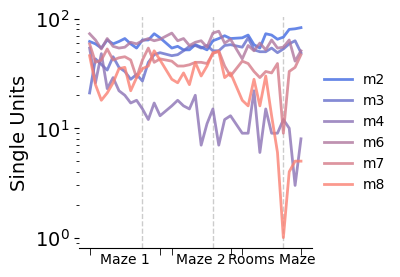

In [ ]:
reload(regions)
sfig1, ax = plt.subplots(1, 1, figsize=(3, 3), clear=True)
regions.plot_single_unit_stability(unit_stability_df, ax=ax)
sfig1.savefig("../results/anatomy/unit_stability.pdf")

In [ ]:
# load both LFP and CSD signal
LFP_signal_df = lfp.load_signal_df(signal_type="LFP")
CSD_signal_df = lfp.load_signal_df(signal_type="CSD")

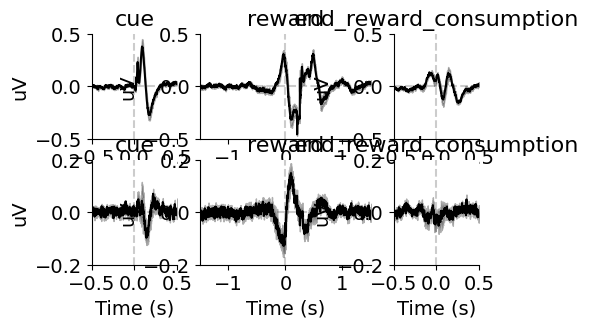

In [ ]:
# plot average of raw signal aligned to event
sfig2, axes = plt.subplots(2, 3, figsize=(5, 3), clear=True, width_ratios=[1, 2, 1])
lfp.plot_av_event_aligned_signal(LFP_signal_df, axes=axes[0, :])
lfp.plot_av_event_aligned_signal(CSD_signal_df, axes=axes[1, :])
for ax in axes[0, :]:
    ax.set_ylim(-0.5, 0.5)
for ax in axes[1, :]:
    ax.set_ylim(-0.2, 0.2)
# sfig2.tight_layout()
sfig2.savefig("../results/event_aligned/aligned_signal.pdf")

In [ ]:
CSD_spectrogram_df = lfp.load_spectrogram_df(signal_type="CSD")

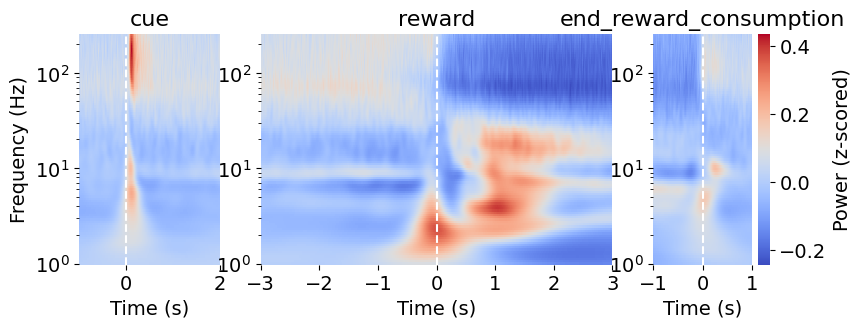

In [ ]:
sfig3, axes = plt.subplots(1, 3, figsize=(9, 3), width_ratios=[0.4, 1, 0.35], clear=True)
lfp.plot_average_spectrogram(CSD_spectrogram_df, axes=axes)
sfig3.savefig("../results/event_aligned/CSD_spectrogram.pdf")

In [ ]:
# event aligned heatmaps to supplement trial-aligned version
sessions = ch.get_sessions_for_analysis(aligned_to="event")
event_aligned_rates_df, ordering_df = ch.get_event_aligned_rates(sessions)

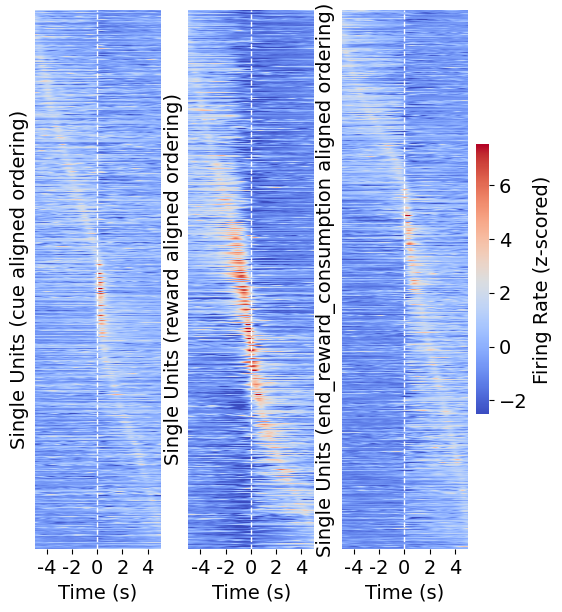

In [ ]:
sfig4, axes = plt.subplots(1, 3, figsize=(6, 7), clear=True, width_ratios=[1, 1, 1.25])
ch.plot_event_aligned_rates(event_aligned_rates_df, ordering_df, axes=axes)
sfig4.savefig("../results/event_aligned/event_aligned_cluster_heatmap.pdf")

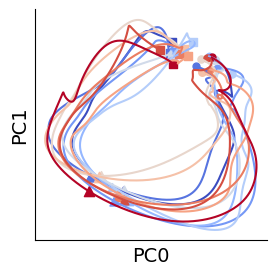

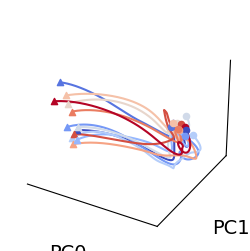

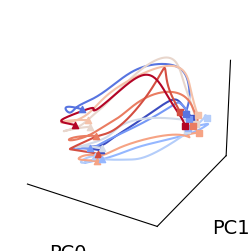

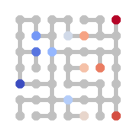

In [6]:
# pca neural trajectory plots
from GridMaze.analysis.population import dynamics as dyn

reload(dyn)
f2D, f3D_1, f3D_2, fL = dyn.plot_example_PC_trajectories(
    maze_name="maze_1",
    goal_subset="subset_2",
    late_sessions=False,
    PCs=(0, 1, 2),
    single_units=True,
)

# saave figures
f2D.savefig("../results/population_dynamics/PC_trajectories_2D.pdf")
f3D_1.savefig("../results/population_dynamics/PC_trajectories_3D_1.pdf")
f3D_2.savefig("../results/population_dynamics/PC_trajectories_3D_2.pdf")
fL.savefig("../results/population_dynamics/PC_trajectories_legend.pdf")